# Análise de Performance — Simulador de Livro de Ofertas

**Disciplina:** Estrutura de Dados em Python  
**Integrantes:** Eduardo, Felipe, Fernando, Nicolas e Victor

## 1. Objetivo

Este notebook mede o desempenho das estruturas lineares implementadas manualmente no simulador de livro de ofertas:

- **Fila (Queue):** Operações FIFO para entrada de ordens — O(1) por operação.
- **Pilha (Stack):** Operações LIFO para undo — O(1) por operação.
- **Lista Duplamente Encadeada (DoublyLinkedList):** Inserção ordenada para manter compras (preço decrescente) e vendas (preço crescente) — O(n) por inserção.

O objetivo é verificar empiricamente como o custo O(n) da inserção ordenada impacta o tempo total de processamento conforme o volume de ordens cresce.

## 2. Importação do Simulador

In [1]:
import sys
import time
import random
from pathlib import Path
from datetime import datetime

ROOT = Path.cwd().parent
FINAL_DIR = ROOT / "final"
if str(FINAL_DIR) not in sys.path:
    sys.path.append(str(FINAL_DIR))

from simulador_livro_ofertas import Order, OrderBook

print('Importação realizada com sucesso.')

Importação realizada com sucesso.


## 3. Geração de Ordens Simuladas

Função para gerar ordens de compra e venda aleatórias em grandes volumes.

In [2]:
def gerar_ordens(quantidade):
    """Gera uma lista de ordens aleatórias (compra e venda intercaladas)."""
    ordens = []
    timestamp_base = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    for i in range(1, quantidade + 1):
        tipo = 'C' if i % 2 == 1 else 'V'
        preco = round(random.uniform(10.0, 500.0), 2)
        quantidade = random.randint(1, 100)
        ordens.append(Order(
            id=i,
            tipo=tipo,
            preco=preco,
            quantidade=quantidade,
            timestamp=timestamp_base
        ))
    return ordens

print('Função de geração definida.')

Função de geração definida.


## 4. Função de Teste

Para cada volume, medimos:
- Tempo de inserção na fila
- Tempo de processamento (fila + match + inserção ordenada no livro)
- Tempo total
- Tempo médio por ordem

In [3]:
def testar_volume(ordens):
    """Executa o fluxo completo para um lote de ordens e mede os tempos."""
    book = OrderBook()
    qtde = len(ordens)

    # Medir inserção na fila
    inicio_insercao = time.perf_counter()
    for o in ordens:
        book.add_order(o)
    fim_insercao = time.perf_counter()
    tempo_insercao = fim_insercao - inicio_insercao

    # Medir processamento completo
    inicio_processamento = time.perf_counter()
    book.process_all_orders()
    fim_processamento = time.perf_counter()
    tempo_processamento = fim_processamento - inicio_processamento

    tempo_total = tempo_insercao + tempo_processamento
    tempo_medio = tempo_total / qtde if qtde > 0 else 0

    return {
        'quantidade': qtde,
        'tempo_insercao': tempo_insercao,
        'tempo_processamento': tempo_processamento,
        'tempo_total': tempo_total,
        'tempo_medio': tempo_medio
    }

print('Função de teste definida.')

Função de teste definida.


## 5. Execução dos Testes

Testamos com 1.000, 5.000 e 10.000 ordens.  
Volumes maiores (50.000, 100.000) são opcionais — descomente se o ambiente permitir.

In [4]:
VOLUMES = [1000, 5000, 10000]
# VOLUMES = [1000, 5000, 10000, 50000, 100000]  # Descomente se quiser testar volumes maiores

resultados = []

for vol in VOLUMES:
    print(f'Testando com {vol} ordens...')
    ordens = gerar_ordens(vol)
    res = testar_volume(ordens)
    resultados.append(res)
    print(f'  Inserção: {res["tempo_insercao"]:.4f}s')
    print(f'  Processamento: {res["tempo_processamento"]:.4f}s')
    print(f'  Total: {res["tempo_total"]:.4f}s')
    print(f'  Médio/ordem: {res["tempo_medio"]:.6f}s')
    print()

print('Testes concluídos.')

Testando com 1000 ordens...
Ordem 1 (C) recebida e adicionada à fila.
Ordem 2 (V) recebida e adicionada à fila.
Ordem 3 (C) recebida e adicionada à fila.
Ordem 4 (V) recebida e adicionada à fila.
Ordem 5 (C) recebida e adicionada à fila.
Ordem 6 (V) recebida e adicionada à fila.
Ordem 7 (C) recebida e adicionada à fila.
Ordem 8 (V) recebida e adicionada à fila.
Ordem 9 (C) recebida e adicionada à fila.
Ordem 10 (V) recebida e adicionada à fila.
Ordem 11 (C) recebida e adicionada à fila.
Ordem 12 (V) recebida e adicionada à fila.
Ordem 13 (C) recebida e adicionada à fila.
Ordem 14 (V) recebida e adicionada à fila.
Ordem 15 (C) recebida e adicionada à fila.
Ordem 16 (V) recebida e adicionada à fila.
Ordem 17 (C) recebida e adicionada à fila.
Ordem 18 (V) recebida e adicionada à fila.
Ordem 19 (C) recebida e adicionada à fila.
Ordem 20 (V) recebida e adicionada à fila.
Ordem 21 (C) recebida e adicionada à fila.
Ordem 22 (V) recebida e adicionada à fila.
Ordem 23 (C) recebida e adicionada 


Retirando ordem 3248 da fila e executing match...

Retirando ordem 3249 da fila e executing match...

Retirando ordem 3250 da fila e executing match...
NEGÓCIO FECHADO! 32 un. negociadas a R$ 309.85

Retirando ordem 3251 da fila e executing match...

Retirando ordem 3252 da fila e executing match...

Retirando ordem 3253 da fila e executing match...

Retirando ordem 3254 da fila e executing match...

Retirando ordem 3255 da fila e executing match...
NÉGOCIO FECHADO! 8 un. negociadas a R$ 357.82
NÉGOCIO FECHADO! 21 un. negociadas a R$ 358.02

Retirando ordem 3256 da fila e executing match...
NEGÓCIO FECHADO! 11 un. negociadas a R$ 309.85

Retirando ordem 3257 da fila e executing match...
NÉGOCIO FECHADO! 36 un. negociadas a R$ 358.02

Retirando ordem 3258 da fila e executing match...
NEGÓCIO FECHADO! 9 un. negociadas a R$ 360.63

Retirando ordem 3259 da fila e executing match...

Retirando ordem 3260 da fila e executing match...

Retirando ordem 3261 da fila e executing match...

Retir



Retirando ordem 2005 da fila e executing match...
NÉGOCIO FECHADO! 45 un. negociadas a R$ 235.49
NÉGOCIO FECHADO! 4 un. negociadas a R$ 353.96

Retirando ordem 2006 da fila e executing match...

Retirando ordem 2007 da fila e executing match...

Retirando ordem 2008 da fila e executing match...

Retirando ordem 2009 da fila e executing match...
NÉGOCIO FECHADO! 51 un. negociadas a R$ 222.07
NÉGOCIO FECHADO! 21 un. negociadas a R$ 353.96
NÉGOCIO FECHADO! 13 un. negociadas a R$ 358.66
NÉGOCIO FECHADO! 12 un. negociadas a R$ 363.99

Retirando ordem 2010 da fila e executing match...
NEGÓCIO FECHADO! 32 un. negociadas a R$ 178.60

Retirando ordem 2011 da fila e executing match...
NÉGOCIO FECHADO! 12 un. negociadas a R$ 136.92

Retirando ordem 2012 da fila e executing match...

Retirando ordem 2013 da fila e executing match...
NÉGOCIO FECHADO! 4 un. negociadas a R$ 136.92
NÉGOCIO FECHADO! 25 un. negociadas a R$ 330.80

Retirando ordem 2014 da fila e executing match...

Retirando ordem 2015

NÉGOCIO FECHADO! 41 un. negociadas a R$ 236.04
NÉGOCIO FECHADO! 58 un. negociadas a R$ 240.03

Retirando ordem 3906 da fila e executing match...
NEGÓCIO FECHADO! 28 un. negociadas a R$ 186.59

Retirando ordem 3907 da fila e executing match...

Retirando ordem 3908 da fila e executing match...
NEGÓCIO FECHADO! 58 un. negociadas a R$ 186.59
NEGÓCIO FECHADO! 13 un. negociadas a R$ 149.29

Retirando ordem 3909 da fila e executing match...
NÉGOCIO FECHADO! 26 un. negociadas a R$ 240.03
NÉGOCIO FECHADO! 9 un. negociadas a R$ 251.54

Retirando ordem 3910 da fila e executing match...

Retirando ordem 3911 da fila e executing match...

Retirando ordem 3912 da fila e executing match...

Retirando ordem 3913 da fila e executing match...
NÉGOCIO FECHADO! 3 un. negociadas a R$ 251.54
NÉGOCIO FECHADO! 3 un. negociadas a R$ 259.55
NÉGOCIO FECHADO! 33 un. negociadas a R$ 269.17

Retirando ordem 3914 da fila e executing match...

Retirando ordem 3915 da fila e executing match...
NÉGOCIO FECHADO! 10 un.

NEGÓCIO FECHADO! 1 un. negociadas a R$ 194.33
NEGÓCIO FECHADO! 26 un. negociadas a R$ 143.90

Retirando ordem 4297 da fila e executing match...
NÉGOCIO FECHADO! 30 un. negociadas a R$ 357.54
NÉGOCIO FECHADO! 27 un. negociadas a R$ 358.50

Retirando ordem 4298 da fila e executing match...

Retirando ordem 4299 da fila e executing match...

Retirando ordem 4300 da fila e executing match...

Retirando ordem 4301 da fila e executing match...

Retirando ordem 4302 da fila e executing match...

Retirando ordem 4303 da fila e executing match...
NÉGOCIO FECHADO! 19 un. negociadas a R$ 239.20
NÉGOCIO FECHADO! 32 un. negociadas a R$ 327.38

Retirando ordem 4304 da fila e executing match...
NEGÓCIO FECHADO! 59 un. negociadas a R$ 177.22
NEGÓCIO FECHADO! 20 un. negociadas a R$ 143.90

Retirando ordem 4305 da fila e executing match...

Retirando ordem 4306 da fila e executing match...

Retirando ordem 4307 da fila e executing match...

Retirando ordem 4308 da fila e executing match...
NEGÓCIO FECHA


NÉGOCIO FECHADO! 7 un. negociadas a R$ 333.89

Retirando ordem 7266 da fila e executing match...
NEGÓCIO FECHADO! 23 un. negociadas a R$ 178.80

Retirando ordem 7267 da fila e executing match...
NÉGOCIO FECHADO! 26 un. negociadas a R$ 333.89

Retirando ordem 7268 da fila e executing match...
NEGÓCIO FECHADO! 4 un. negociadas a R$ 178.80
NEGÓCIO FECHADO! 9 un. negociadas a R$ 177.47

Retirando ordem 7269 da fila e executing match...
NÉGOCIO FECHADO! 20 un. negociadas a R$ 333.89

Retirando ordem 7270 da fila e executing match...

Retirando ordem 7271 da fila e executing match...
NÉGOCIO FECHADO! 3 un. negociadas a R$ 255.68

Retirando ordem 7272 da fila e executing match...
NEGÓCIO FECHADO! 9 un. negociadas a R$ 272.27
NEGÓCIO FECHADO! 23 un. negociadas a R$ 177.47

Retirando ordem 7273 da fila e executing match...

Retirando ordem 7274 da fila e executing match...

Retirando ordem 7275 da fila e executing match...
NÉGOCIO FECHADO! 40 un. negociadas a R$ 333.89
NÉGOCIO FECHADO! 20 un. 



Retirando ordem 9876 da fila e executing match...
NEGÓCIO FECHADO! 88 un. negociadas a R$ 248.95

Retirando ordem 9877 da fila e executing match...

Retirando ordem 9878 da fila e executing match...
NEGÓCIO FECHADO! 10 un. negociadas a R$ 248.95
NEGÓCIO FECHADO! 18 un. negociadas a R$ 217.60
NEGÓCIO FECHADO! 50 un. negociadas a R$ 205.76

Retirando ordem 9879 da fila e executing match...

Retirando ordem 9880 da fila e executing match...

Retirando ordem 9881 da fila e executing match...

Retirando ordem 9882 da fila e executing match...
NEGÓCIO FECHADO! 88 un. negociadas a R$ 300.78

Retirando ordem 9883 da fila e executing match...
NÉGOCIO FECHADO! 9 un. negociadas a R$ 241.45
NÉGOCIO FECHADO! 1 un. negociadas a R$ 301.09
NÉGOCIO FECHADO! 17 un. negociadas a R$ 305.33

Retirando ordem 9884 da fila e executing match...

Retirando ordem 9885 da fila e executing match...
NÉGOCIO FECHADO! 40 un. negociadas a R$ 305.33

Retirando ordem 9886 da fila e executing match...

Retirando ordem 

## 6. Tabela de Resultados

In [5]:
print(f"{'Ordens':>8} | {'Inserção (s)':>12} | {'Process. (s)':>12} | {'Total (s)':>10} | {'Médio (s)':>10}")
print("-" * 60)
for r in resultados:
    print(f"{r['quantidade']:>8} | {r['tempo_insercao']:>10.4f}  | {r['tempo_processamento']:>10.4f}  | {r['tempo_total']:>8.4f}  | {r['tempo_medio']:>8.6f}")

  Ordens | Inserção (s) | Process. (s) |  Total (s) |  Médio (s)
------------------------------------------------------------
    1000 |     0.0070  |     0.0162  |   0.0231  | 0.000023
    5000 |     0.0331  |     0.1481  |   0.1812  | 0.000036
   10000 |     0.0943  |     0.4493  |   0.5437  | 0.000054


## 7. Gráficos de Performance

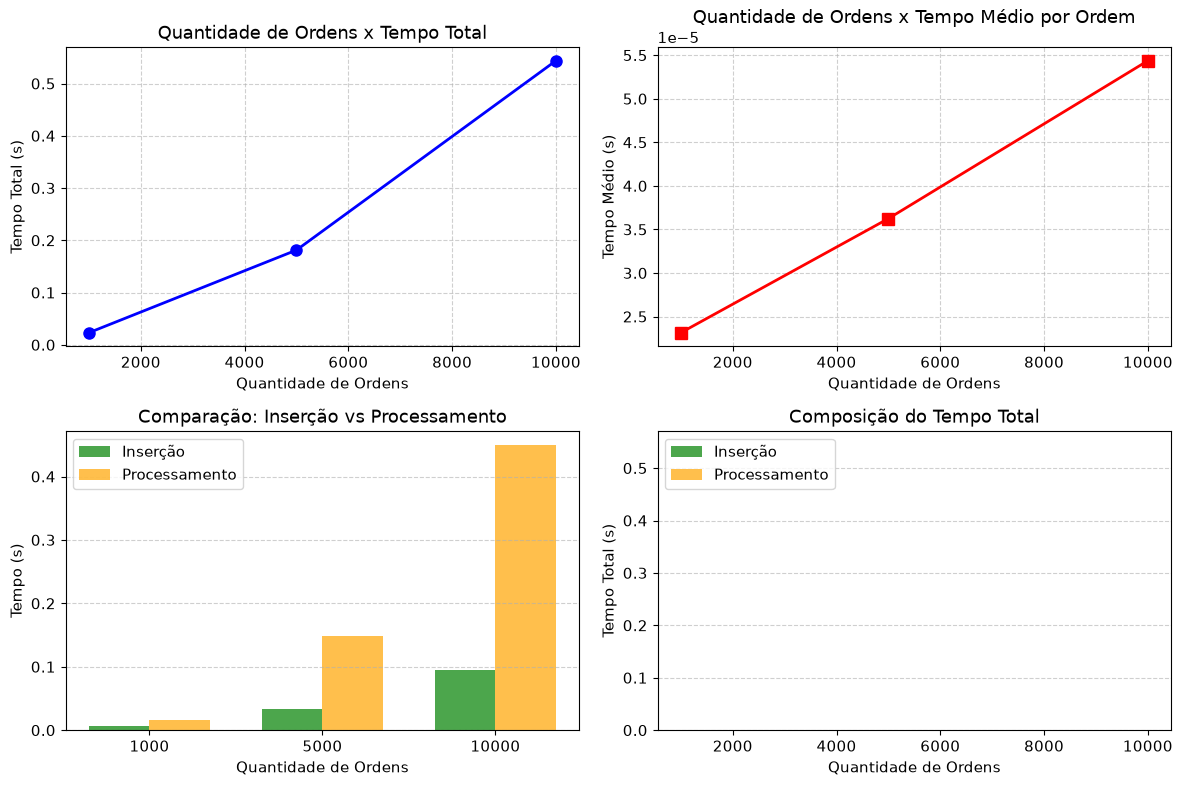

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

quantidades = [r['quantidade'] for r in resultados]
tempos_total = [r['tempo_total'] for r in resultados]
tempos_medio = [r['tempo_medio'] for r in resultados]
tempos_insercao = [r['tempo_insercao'] for r in resultados]
tempos_processamento = [r['tempo_processamento'] for r in resultados]

# Gráfico 1: Quantidade de ordens x Tempo total
plt.subplot(2, 2, 1)
plt.plot(quantidades, tempos_total, 'bo-', linewidth=2, markersize=8)
plt.title('Quantidade de Ordens x Tempo Total')
plt.xlabel('Quantidade de Ordens')
plt.ylabel('Tempo Total (s)')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Quantidade de ordens x Tempo médio por ordem
plt.subplot(2, 2, 2)
plt.plot(quantidades, tempos_medio, 'rs-', linewidth=2, markersize=8)
plt.title('Quantidade de Ordens x Tempo Médio por Ordem')
plt.xlabel('Quantidade de Ordens')
plt.ylabel('Tempo Médio (s)')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Comparação Inserção vs Processamento
plt.subplot(2, 2, 3)
largura = 0.35
x = range(len(quantidades))
plt.bar([i - largura/2 for i in x], tempos_insercao, largura, label='Inserção', color='green', alpha=0.7)
plt.bar([i + largura/2 for i in x], tempos_processamento, largura, label='Processamento', color='orange', alpha=0.7)
plt.title('Comparação: Inserção vs Processamento')
plt.xlabel('Quantidade de Ordens')
plt.ylabel('Tempo (s)')
plt.xticks(x, quantidades)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Gráfico 4: Proporção do tempo total
plt.subplot(2, 2, 4)
for i, r in enumerate(resultados):
    plt.bar(r['quantidade'], r['tempo_insercao'], label='Inserção' if i == 0 else '', color='green', alpha=0.7)
    plt.bar(r['quantidade'], r['tempo_processamento'], bottom=r['tempo_insercao'],
            label='Processamento' if i == 0 else '', color='orange', alpha=0.7)
plt.title('Composição do Tempo Total')
plt.xlabel('Quantidade de Ordens')
plt.ylabel('Tempo Total (s)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Análise dos Resultados

### Comportamento observado

- **Fila e Pilha:** As operações de extremidade (enqueue, dequeue, push, pop) têm complexidade O(1), portanto o custo de inserção na fila cresce linearmente com o volume, sem surpresas.

- **Lista Duplamente Encadeada Ordenada:** A inserção ordenada exige busca linear O(n) para encontrar a posição correta. Como cada ordem processada pode ser inserida no livro, e o livro cresce conforme novas ordens são adicionadas, o custo acumulado tende a crescer de forma aproximadamente quadrática O(n²) no pior caso.

- **Impacto no tempo total:** Conforme o volume de ordens aumenta, o tempo de processamento cresce mais que o tempo de inserção, porque o motor de match percorre a lista encadeada para inserir ordens que não encontraram match imediato.

### Explicação da complexidade

| Estrutura | Operação | Complexidade |
|---|---|---|
| Queue | enqueue / dequeue | O(1) |
| Stack | push / pop | O(1) |
| DoublyLinkedList | inserção ordenada | O(n) |
| DoublyLinkedList | remoção por ID | O(n) |
| DoublyLinkedList | busca linear | O(n) |

### Conclusão

Os resultados empíricos estão alinhados com a complexidade teórica esperada.  
A lista duplamente encadeada ordenada é o gargalo do sistema, como previsto.

Essa análise serve como base para comparação futura com estruturas não-lineares (como árvores binárias de busca ou heaps), que poderiam reduzir a inserção ordenada para O(log n).